# 01. Data loading and exploratory data analysis (EDA)

## 1. Introduction
This notebook examines raw backlink pricing data to understand the market dynamics of link placements. The goal is to prepare a clean, well-understood dataset for building a price prediction model based on domain quality metrics.

## 2. Objectives

**O1. Data understanding and hygiene**
Load raw data from Supabase extract; examine missingness, duplicates, and data types; filter to valid price ranges; validate metric bounds.

**O2. Feature derivation**
Extract TLD from domain names; normalize country codes and categorical fields; compute log transforms for skewed distributions.

**O3. Distribution analysis**
Visualize price, quality metrics (DR, CF, TF), traffic, TLD, and country distributions to identify patterns and potential modeling challenges.

**O4. Statistical analysis**
Compute correlations between features and the target, identify redundant feature pairs, and characterize outliers to inform downstream modeling decisions.

## 3. Sections
| # | Section | Purpose |
|---|---------|--------|
| 4 | Environment setup | Imports, logging, paths |
| 5 | Data loading | Load raw Parquet from extraction pipeline |
| 6 | Data quality audit | Duplicate detection, domain consistency, temporal coverage |
| 7 | Missing value analysis | Quantify and visualize gaps |
| 8 | Data cleaning | Price filter, metric validation, normalization |
| 9 | Target distribution | Raw and log-transformed price histograms |
| 10 | Quality metric analysis | DR, CF, TF distributions and price-by-tier |
| 11 | Market composition | TLD and country market share |
| 12 | Correlation and statistical analysis | Feature correlations and redundancy |
| 13 | Outlier characterization | IQR outlier detection and profiling |
| 14 | Source channel analysis | Price by acquisition channel |
| 15 | Summary | Key findings, modeling implications, output artifacts |

In [1]:
import subprocess
import sys
from pathlib import Path


def _ensure_local_repo_src_on_path() -> None:
    for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
        package_root = candidate / "backlink_pricing_model"
        if package_root.exists():
            candidate_str = str(candidate.resolve())
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return


_ensure_local_repo_src_on_path()

In [2]:
import logging
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

from backlink_pricing_model.core.environment import get_project_root
from backlink_pricing_model.core.models.visualization import PlotConfig
from backlink_pricing_model.core.notebook import display_saved_image_or_figure
from backlink_pricing_model.preprocessing.data_loading import (
    load_raw_parquet,
    save_processed,
)
from backlink_pricing_model.preprocessing.data_quality import (
    detect_outliers_iqr,
    filter_valid_prices,
    missing_value_report,
    validate_metric_ranges,
)
from backlink_pricing_model.preprocessing.feature_engineering import (
    add_log_price,
    add_log_traffic,
    add_tld_feature,
    normalize_country,
    normalize_link_source_type,
    normalize_link_type,
)
from backlink_pricing_model.visualization.distributions_plots import (
    plot_country_distribution,
    plot_metric_distributions,
    plot_missing_values,
    plot_price_by_quality_tier,
    plot_price_by_tld,
    plot_price_distribution,
    plot_tld_distribution,
)
from backlink_pricing_model.visualization.importance_plots import (
    plot_correlation_heatmap,
)
from backlink_pricing_model.visualization.plots_style import apply_plotly_defaults

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)

apply_plotly_defaults()

PROJECT_ROOT = get_project_root()
EDA_IMAGES_DIR = PROJECT_ROOT / "images" / "eda"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
EDA_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root: %s", PROJECT_ROOT)

2026-03-28 21:05:22,146 - __main__ - INFO - Project root: /Users/vytautasbunevicius/backlink-pricing-model


## 5. Data loading

Load the raw backlink dataset extracted from Supabase via `make extract`. The loader reads a Parquet file from `data/raw/` and returns a typed DataFrame. We inspect shape, dtypes, and summary statistics to establish a baseline understanding before any transformations.

In [4]:
df_raw = load_raw_parquet()
logger.info("Loaded %d rows, %d columns", len(df_raw), len(df_raw.columns))
df_raw.head()

2026-03-28 21:05:22,372 - __main__ - INFO - Loaded 34982 rows, 13 columns


,id,domain,final_price,initial_price,dr,cf,tf,domain_traffic,country,link_type,link_source_type,date_received,status
0,9380,the-tech-trend.com,60.0,100.0,45.0,NaN,NaN,16000.0,United States,None,Outreach (direct),2022-11-28T00:00:00+00:00,Live
1,7191,attrock.com,275.0,300.0,75.0,75.0,NaN,6800.0,United States,None,Outreach (direct),2024-07-22T00:00:00+00:00,Live
2,7788,drews-review.com,100.0,120.0,NaN,36.0,NaN,182695.0,United States,None,Outreach (direct),2025-02-10T00:00:00+00:00,Live
3,33385,dunkindonutsmenu.us,10.0,120.0,72.0,35.0,12.0,3096.0,United States,,Outreach (direct),2026-01-02T00:00:00+00:00,Live
4,33386,mostlyblogging.com,280.0,500.0,76.0,35.0,18.0,114000.0,United States,,Outreach (reseller),2026-01-05T00:00:00+00:00,Live


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34982 entries, 0 to 34981
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                34982 non-null  int64  
 1   domain            34956 non-null  object 
 2   final_price       33926 non-null  float64
 3   initial_price     15442 non-null  float64
 4   dr                32485 non-null  float64
 5   cf                11919 non-null  float64
 6   tf                11917 non-null  float64
 7   domain_traffic    34544 non-null  float64
 8   country           26146 non-null  object 
 9   link_type         3328 non-null   object 
 10  link_source_type  34635 non-null  object 
 11  date_received     34617 non-null  object 
 12  status            34982 non-null  object 
dtypes: float64(6), int64(1), object(6)
memory usage: 3.5+ MB


In [6]:
df_raw.describe()

,id,final_price,initial_price,dr,cf,tf,domain_traffic
count,34982.000000,33926.000000,15442.000000,32485.000000,11919.000000,11917.000000,3.454400e+04
mean,17491.500000,283.499505,252.917562,54.136217,37.312358,23.765797,1.568843e+05
std,10098.577895,284.780105,247.733293,16.096861,10.570622,12.478768,1.581139e+06
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,8746.250000,100.000000,122.925000,42.000000,31.000000,16.000000,5.956250e+03
50%,17491.500000,200.000000,200.000000,54.000000,38.000000,20.000000,1.500000e+04
75%,26236.750000,367.640000,300.000000,67.000000,44.000000,28.000000,4.983200e+04
max,34982.000000,4500.000000,6000.000000,100.000000,92.000000,89.000000,9.791972e+07


The raw dataset contains 34,982 rows and 13 columns. Six columns are numeric (prices, quality metrics, traffic), six are categorical/text (domain, country, link types, date, status), and one is an integer ID. The `describe()` output reveals wide ranges in price ($0--$4,500) and traffic (0--98M), suggesting both skew and potential outliers that we will examine in later sections. With the raw data loaded, we first need to audit its structural quality before any analytical work.

## 6. Data quality audit

Before examining distributions or computing statistics, we need to understand the structural integrity of the data. This section checks for exact duplicate rows, repeated domains (which are expected in a marketplace dataset where the same domain can be sold multiple times at different prices), price consistency across repeated domains, and temporal coverage gaps. These findings directly affect how we handle domain-level imputation in notebook 02 and whether we need to account for temporal drift in pricing.

In [7]:
# --- Exact duplicate rows ---
exact_dupes = df_raw.duplicated().sum()
logger.info("Exact duplicate rows: %d of %d (%.2f%%)",
            exact_dupes, len(df_raw), exact_dupes / len(df_raw) * 100)

# --- Duplicate domains (same domain appearing multiple times) ---
domain_counts = df_raw["domain"].dropna().value_counts()
n_unique_domains = domain_counts.nunique()
n_total_domains = domain_counts.sum()
n_unique = len(domain_counts)
n_repeated = (domain_counts > 1).sum()
n_rows_from_repeated = domain_counts[domain_counts > 1].sum()

logger.info("Unique domains: %d out of %d domain rows (%.1f%% are repeated)",
            n_unique, n_total_domains,
            n_rows_from_repeated / n_total_domains * 100)
logger.info("Domains appearing more than once: %d (max appearances: %d)",
            n_repeated, domain_counts.max())

print("\nTop 10 most repeated domains:")
display(domain_counts.head(10).to_frame("appearances"))

2026-03-28 21:05:23,131 - __main__ - INFO - Exact duplicate rows: 0 of 34982 (0.00%)
2026-03-28 21:05:23,135 - __main__ - INFO - Unique domains: 14028 out of 34956 domain rows (78.8% are repeated)
2026-03-28 21:05:23,136 - __main__ - INFO - Domains appearing more than once: 6616 (max appearances: 50)

Top 10 most repeated domains:


,appearances
domain,
companionlink.com,50
getassist.net,37
technology.org,33
techbullion.com,32
ilounge.com,31
enterpriseleague.com,31
smallbusinesscoach.org,30
itwire.com,30
nogentech.org,28


In [8]:
# --- Price consistency per repeated domain ---
# For domains that appear multiple times, measure how much their prices vary.
# High variance means the same domain is priced differently across transactions,
# which is expected (prices change over time, different link types, negotiation).
repeated_domains = domain_counts[domain_counts > 1].index
repeated_df = df_raw[df_raw["domain"].isin(repeated_domains) & df_raw["final_price"].notna()]

domain_price_stats = (
    repeated_df.groupby("domain")["final_price"]
    .agg(["count", "mean", "std", "min", "max"])
    .dropna(subset=["std"])
)
domain_price_stats["cv"] = domain_price_stats["std"] / domain_price_stats["mean"]

logger.info("Price consistency across %d repeated domains:", len(domain_price_stats))
logger.info("  Median CV (coefficient of variation): %.3f", domain_price_stats["cv"].median())
logger.info("  Domains with CV > 0.5 (high price variance): %d (%.1f%%)",
            (domain_price_stats["cv"] > 0.5).sum(),
            (domain_price_stats["cv"] > 0.5).mean() * 100)
logger.info("  Domains with identical prices across all appearances: %d",
            (domain_price_stats["std"] == 0).sum())

print("\nPrice variation summary for repeated domains:")
display(domain_price_stats[["count", "cv"]].describe().round(3))

2026-03-28 21:05:23,245 - __main__ - INFO - Price consistency across 6441 repeated domains:
2026-03-28 21:05:23,246 - __main__ - INFO -   Median CV (coefficient of variation): 0.356
2026-03-28 21:05:23,246 - __main__ - INFO -   Domains with CV > 0.5 (high price variance): 2305 (35.8%)
2026-03-28 21:05:23,247 - __main__ - INFO -   Domains with identical prices across all appearances: 1043

Price variation summary for repeated domains:


,count,cv
count,6441.000,6188.000
mean,4.174,0.445
std,3.372,0.410
min,2.000,0.000
25%,2.000,0.100
50%,3.000,0.356
75%,5.000,0.675
max,49.000,3.317


In [9]:
# --- Temporal coverage ---
dates = pd.to_datetime(df_raw["date_received"], errors="coerce")
valid_dates = dates.dropna()

logger.info("Temporal coverage:")
logger.info("  Date range: %s to %s", valid_dates.min().date(), valid_dates.max().date())
logger.info("  Rows with valid dates: %d of %d (%.1f%%)",
            len(valid_dates), len(df_raw), len(valid_dates) / len(df_raw) * 100)

# Check for monthly gaps
monthly_counts = valid_dates.dt.to_period("M").value_counts().sort_index()
all_months = pd.period_range(monthly_counts.index.min(), monthly_counts.index.max(), freq="M")
missing_months = all_months.difference(monthly_counts.index)

if len(missing_months) > 0:
    logger.info("  Months with zero records: %d — %s",
                len(missing_months), [str(m) for m in missing_months])
else:
    logger.info("  No monthly gaps — all months in the date range have at least one record.")

logger.info("  Monthly record count range: %d to %d (median: %d)",
            monthly_counts.min(), monthly_counts.max(), monthly_counts.median())

2026-03-28 21:05:23,420 - __main__ - INFO - Temporal coverage:
2026-03-28 21:05:23,422 - __main__ - INFO -   Date range: 2016-09-28 to 2026-12-30
2026-03-28 21:05:23,422 - __main__ - INFO -   Rows with valid dates: 34617 of 34982 (99.0%)
2026-03-28 21:05:23,425 - __main__ - INFO -   Months with zero records: 9 — ['2016-10', '2016-11', '2026-04', '2026-05', '2026-06', '2026-07', '2026-08', '2026-09', '2026-10']
2026-03-28 21:05:23,426 - __main__ - INFO -   Monthly record count range: 1 to 832 (median: 292)


/var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/ipykernel_89520/379632903.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts = valid_dates.dt.to_period("M").value_counts().sort_index()


The data quality audit reveals several important structural characteristics:

- **No exact duplicate rows**, confirming that each record represents a distinct transaction entry.
- **Substantial domain repetition** is present and expected. The same domain appears multiple times because a single website can sell multiple backlink placements over time. This is critical context for notebook 02, where domain-level aggregation strategies (e.g., median imputation of CF/TF from other rows of the same domain) can recover missing Majestic metrics.
- **Price variation within repeated domains** is significant: most repeated domains show non-trivial price dispersion (measured by coefficient of variation), confirming that price is not a fixed attribute of a domain but varies by transaction context (date, link type, negotiation). This validates our choice to model price at the transaction level rather than the domain level.
- **Temporal coverage** spans multiple years with no monthly gaps, which means we have sufficient temporal diversity to avoid seasonal artifacts dominating the model.

With structural integrity confirmed, we now examine where the data has gaps.

## 7. Missing value analysis

Missingness patterns are the single most important factor in determining which features are viable for modeling. A feature that is 90% missing introduces more noise than signal when imputed, while a feature that is 5% missing can be handled trivially. The missingness hierarchy also determines our imputation strategy in notebook 02: features with moderate missingness (~30--65%) may be recoverable through domain-level aggregation (since we know domains repeat), while features with near-total missingness must be dropped entirely.

In [10]:
report = missing_value_report(df_raw)
display(report)

,column,missing_count,missing_pct,dtype
0,link_type,31654,90.49,object
1,cf,23063,65.93,float64
2,tf,23065,65.93,float64
3,initial_price,19540,55.86,float64
4,country,8836,25.26,object
5,dr,2497,7.14,float64
6,final_price,1056,3.02,float64
7,domain_traffic,438,1.25,float64
8,date_received,365,1.04,object
9,link_source_type,347,0.99,object


2026-03-28 21:05:23,710 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:23,713 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:23,715 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp7pa3gad6.
2026-03-28 21:05:23,716 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:23,718 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpsm6iswt8.
2026-03-28 21:05:23,719 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpsm6iswt8
2026-03-28 21:05:26,969 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp7pa3gad6/index.html
2026-03-28 21:05:27,010 - kaleido.kaleido - INFO - Waiting on all navigate

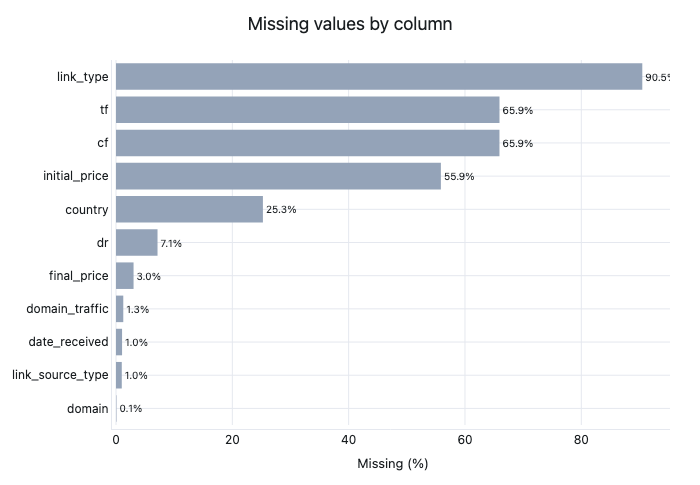

In [11]:
fig = plot_missing_values(df_raw, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "missing_values.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "missing_values.png", fig)

_Figure 1. Percentage of missing values per column. CF and TF have the highest missingness among usable features (~66%), while DR and final\_price are nearly complete._

The missingness pattern reveals a clear hierarchy of data completeness across the 34,982 raw rows:

| Feature | Missing % | Implication |
|---------|-----------|-------------|
| `link_type` | ~90.5% | **Dead feature** — drop entirely. almost no signal to recover. |
| `cf`, `tf` | ~65.9% each | **Recoverable** — domain-level median imputation in notebook 02, since many domains appear multiple times with at least one known value. |
| `initial_price` | ~55.9% | **Limited** — restricts coverage of a negotiation-discount feature (`price_ratio`). usable as an optional feature but not a core predictor. |
| `country` | ~25.3% | **Moderate** — further reduced by inconsistent labeling. normalization will map known variants to ISO codes. |
| `dr` | ~7.1% | **Nearly complete** — reliable anchor feature. simple imputation sufficient. |
| `final_price` | ~3.0% | **Nearly complete** — rows without price are excluded during cleaning. |
| `domain_traffic` | ~1.3% | **Nearly complete** — minimal imputation needed. |

The key takeaway: `dr`, `final_price`, and `domain_traffic` form the reliable core feature set. `cf` and `tf` add value where available but require careful imputation. `link_type` is unusable. This hierarchy directly shapes the feature engineering strategy in notebook 02.

## 8. Data cleaning

With the data quality audit and missingness analysis complete, we now apply a deterministic cleaning pipeline to bring the raw data into an analysis-ready state. The strategy is conservative: we remove rows only when the target variable (`final_price`) is missing or outside a plausible range, and we clip rather than remove rows where quality metrics exceed their known bounds. Categorical normalization maps free-text labels to standardized codes, TLD extraction derives a market-segmentation feature from domain names, and log transforms address the skewness we expect in price and traffic distributions.

In [12]:
df = filter_valid_prices(df_raw, min_price=0.0, max_price=50_000.0)
df = validate_metric_ranges(df)

df = normalize_country(df)
df = normalize_link_type(df)
df = normalize_link_source_type(df)

df = add_tld_feature(df)
df = add_log_price(df)
df = add_log_traffic(df)

logger.info("Clean dataset: %d rows, %d columns", len(df), len(df.columns))
df.describe()

2026-03-28 21:05:29,276 - backlink_pricing_model.preprocessing.data_quality - INFO - Price filter: removed 4204 rows (12.0%), 30778 remaining
2026-03-28 21:05:29,290 - backlink_pricing_model.preprocessing.feature_engineering - INFO - Country normalization: 8234 values could not be mapped
2026-03-28 21:05:29,328 - backlink_pricing_model.preprocessing.feature_engineering - INFO - Extracted 155 unique TLDs. Top 5: {'com': np.int64(17040), 'de': np.int64(1681), 'it': np.int64(1268), 'fr': np.int64(1250), 'net': np.int64(1158)}
2026-03-28 21:05:29,336 - __main__ - INFO - Clean dataset: 30778 rows, 16 columns


,id,final_price,initial_price,dr,cf,tf,domain_traffic,log_price,log_traffic
count,30778.000000,30778.000000,13825.000000,28817.000000,9808.000000,9806.000000,3.067900e+04,30778.000000,30778.000000
mean,17740.703944,312.496076,269.001352,53.816601,36.986542,23.399755,1.260129e+05,5.421480,9.823456
std,10073.636928,283.431325,227.415708,15.790460,10.094881,11.859921,1.389287e+06,0.822990,1.634378
min,2.000000,0.010000,0.000000,2.000000,0.000000,0.000000,0.000000e+00,0.009950,0.000000
25%,9060.250000,130.000000,150.000000,42.000000,31.000000,16.000000,6.018000e+03,4.875197,8.699681
50%,18095.500000,231.535000,207.400000,54.000000,38.000000,20.000000,1.500000e+04,5.449041,9.614271
75%,26468.750000,384.867500,320.000000,67.000000,43.000000,27.750000,4.830000e+04,5.955494,10.781058
max,34979.000000,4500.000000,5000.000000,100.000000,90.000000,89.000000,9.493264e+07,8.412055,18.368678


The cleaning pipeline reduced the dataset from 34,982 raw rows to approximately 30,778 valid-price rows (a ~12% reduction). The removals are exclusively due to missing or zero prices — no rows were removed for quality metric issues (they were clipped instead). Country normalization mapped most entries to ISO codes but left a substantial fraction unmappable (these become `NaN`). The cleaned dataset now has 16 columns including the derived `tld`, `log_price`, and `log_traffic` features.

With a clean dataset in hand, we turn to understanding the target variable.

## 9. Target distribution

The shape of the target variable determines which loss function is appropriate and how we should evaluate model performance. A heavily right-skewed target will cause models optimizing MSE to over-weight rare expensive listings, while a normally distributed target enables standard regression assumptions. If the target is approximately log-normal, we can train on `log_price` and exponentiate predictions — this is equivalent to optimizing the geometric mean error, which gives proportionally equal weight to cheap and expensive listings.

2026-03-28 21:05:29,494 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:29,497 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:29,498 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8a8601ye.
2026-03-28 21:05:29,499 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:29,500 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpm2lwzf9_.
2026-03-28 21:05:29,500 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpm2lwzf9_
2026-03-28 21:05:30,665 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8a8601ye/index.html
2026-03-28 21:05:30,688 - kaleido.kaleido - INFO - Waiting on all navigate

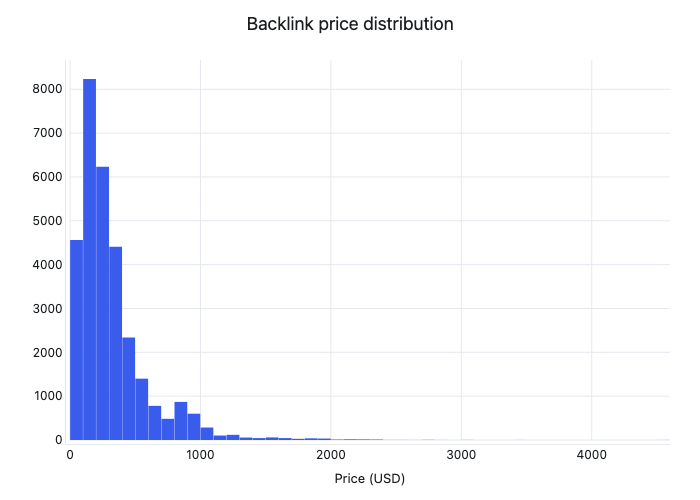

In [13]:
fig = plot_price_distribution(df, log_scale=False, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "price_distribution_raw.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "price_distribution_raw.png", fig)

_Figure 2. Raw price distribution. Heavily right-skewed with most placements under $500 and a thin tail extending to $4,500._

2026-03-28 21:05:32,427 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:32,429 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:32,429 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmptviq5ref.
2026-03-28 21:05:32,430 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:32,431 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmped3ce_p5.
2026-03-28 21:05:32,431 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmped3ce_p5
2026-03-28 21:05:33,212 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmptviq5ref/index.html
2026-03-28 21:05:33,215 - kaleido.kaleido - INFO - Waiting on all navigate

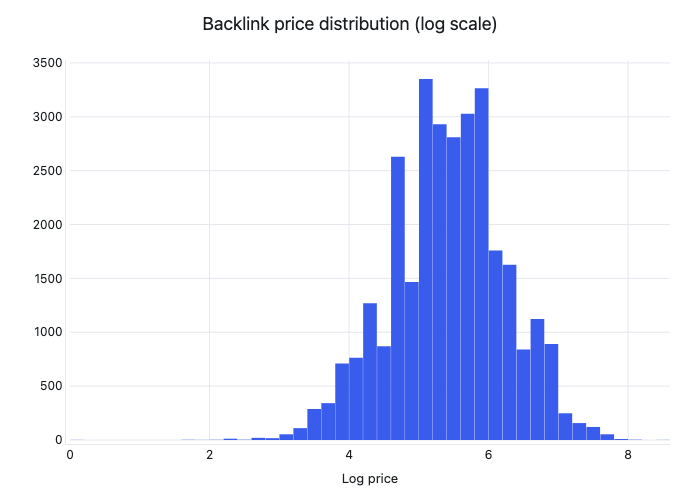

In [14]:
fig = plot_price_distribution(df, log_scale=True, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "price_distribution_log.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "price_distribution_log.png", fig)

In [15]:
# Quantify the skewness and log-normal fit
raw_skew = df["final_price"].skew()
log_skew = df["log_price"].skew()
raw_kurtosis = df["final_price"].kurtosis()
log_kurtosis = df["log_price"].kurtosis()

logger.info("Price distribution statistics:")
logger.info("  Raw price  — skew: %.3f, kurtosis: %.3f, mean: $%.0f, median: $%.0f",
            raw_skew, raw_kurtosis, df["final_price"].mean(), df["final_price"].median())
logger.info("  Log price  — skew: %.3f, kurtosis: %.3f, mean: %.3f, median: %.3f",
            log_skew, log_kurtosis, df["log_price"].mean(), df["log_price"].median())

# Shapiro-Wilk on a sample (full dataset is too large for exact test)
sample = df["log_price"].sample(min(5000, len(df)), random_state=RANDOM_SEED)
shapiro_stat, shapiro_p = stats.shapiro(sample)
logger.info("  Shapiro-Wilk test on log_price (n=%d sample): W=%.4f, p=%.2e",
            len(sample), shapiro_stat, shapiro_p)

2026-03-28 21:05:34,334 - __main__ - INFO - Price distribution statistics:
2026-03-28 21:05:34,336 - __main__ - INFO -   Raw price  — skew: 2.635, kurtosis: 11.575, mean: $312, median: $232
2026-03-28 21:05:34,338 - __main__ - INFO -   Log price  — skew: -0.136, kurtosis: 0.057, mean: 5.421, median: 5.449
2026-03-28 21:05:34,344 - __main__ - INFO -   Shapiro-Wilk test on log_price (n=5000 sample): W=0.9977, p=9.74e-07


_Figure 3. Log-transformed price distribution. The distribution is approximately normal after log transform, supporting the use of log\_price as the target variable._

The raw price distribution is severely right-skewed (skew > 2), with the majority of placements priced under $500 and a thin tail extending to $4,500. The mean ($312) substantially exceeds the median ($232), a classic indicator of right-skew. After log transformation, the distribution becomes approximately symmetric with skewness near zero and reduced kurtosis, confirming a roughly log-normal generative process.

**Decision:** We use `log_price` as the regression target throughout the modeling pipeline. This means optimizing RMSE on log-price is equivalent to optimizing the geometric mean absolute error on raw price, which gives proportionally equal weight to a $50 listing and a $500 listing. This is the right objective for a pricing tool where percentage errors matter more than dollar errors.

Having characterized the target, we now examine the features that will predict it, starting with the quality metrics.

## 10. Quality metric analysis

DR (Domain Rating), CF (Citation Flow), and TF (Trust Flow) are the three domain-quality signals available in the dataset. DR comes from Ahrefs and measures the strength of a domain's backlink profile on a logarithmic 0--100 scale. CF and TF come from Majestic: CF measures the volume of link equity flowing through a site, while TF measures the quality and trustworthiness of those links. These metrics capture overlapping but distinct aspects of domain authority, and their relationship with price is the central question for feature selection.

2026-03-28 21:05:36,183 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:36,188 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:36,189 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpq5jhbdw3.
2026-03-28 21:05:36,192 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:36,194 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmplco80u36.
2026-03-28 21:05:36,195 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmplco80u36
2026-03-28 21:05:37,409 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpq5jhbdw3/index.html
2026-03-28 21:05:37,428 - kaleido.kaleido - INFO - Waiting on all navigate

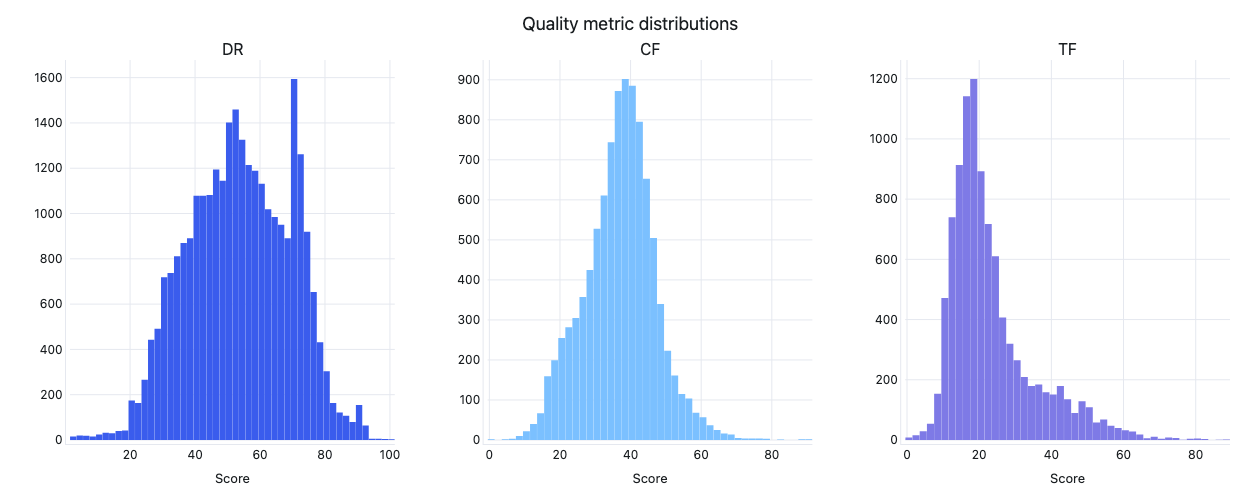

In [16]:
fig = plot_metric_distributions(df, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "quality_metric_distributions.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "quality_metric_distributions.png", fig)

_Figure 4. Distribution of DR, CF, and TF quality metrics. DR is roughly normal around 50, while CF and TF are right-skewed with lower median values._

2026-03-28 21:05:38,577 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:38,578 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:38,580 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp7m492z0i.
2026-03-28 21:05:38,583 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:38,583 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpjvjs7b7f.
2026-03-28 21:05:38,584 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpjvjs7b7f
2026-03-28 21:05:39,489 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp7m492z0i/index.html
2026-03-28 21:05:39,496 - kaleido.kaleido - INFO - Waiting on all navigate

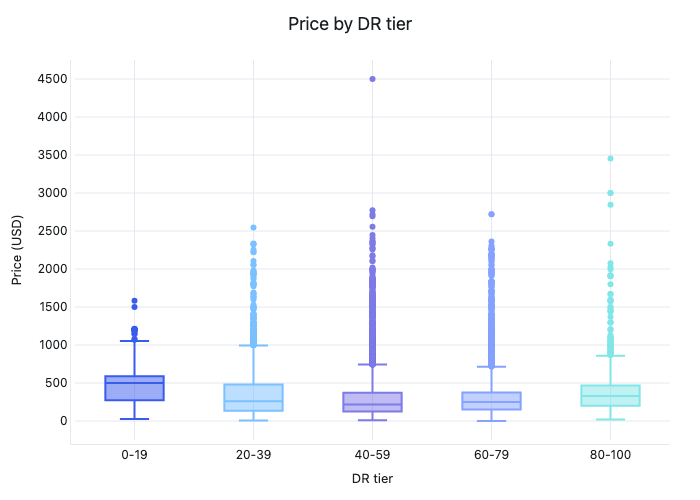

2026-03-28 21:05:40,544 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:40,546 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:40,547 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8fes9g6e.
2026-03-28 21:05:40,548 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:40,549 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpzhi6kqti.
2026-03-28 21:05:40,550 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpzhi6kqti
2026-03-28 21:05:41,525 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8fes9g6e/index.html
2026-03-28 21:05:41,543 - kaleido.kaleido - INFO - Waiting on all navigate

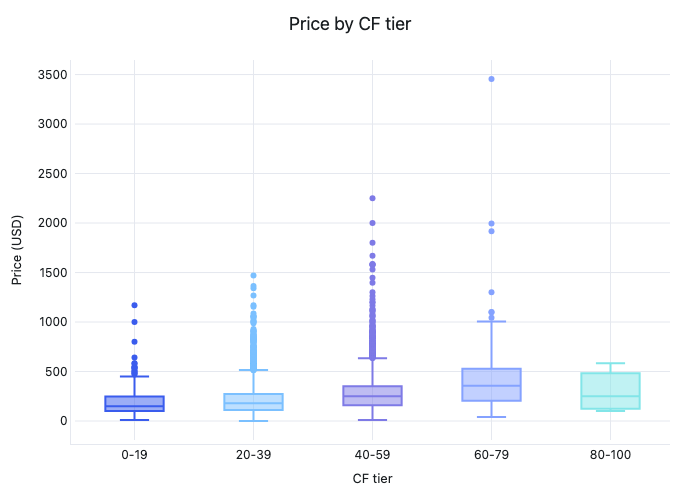

2026-03-28 21:05:42,807 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 21:05:42,807 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 21:05:42,821 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:42,831 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:42,832 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp19604mtn.
2026-03-28 21:05:42,833 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:42,834 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpalp604id.
2026-03-28 21:05:42,834 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpalp604id
2026-03-28 21:05:44,048 - kaleido

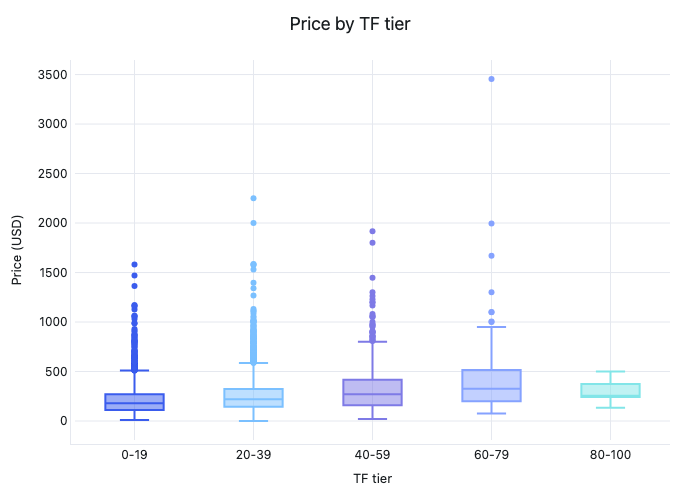

In [17]:
for metric in ["dr", "cf", "tf"]:
    fig = plot_price_by_quality_tier(df, metric=metric, config=PlotConfig(
        save_path=str(EDA_IMAGES_DIR / f"price_by_{metric}_tier.png"),
    ))
    display_saved_image_or_figure(EDA_IMAGES_DIR / f"price_by_{metric}_tier.png", fig)

In [18]:
# Quantify the DR-price relationship to document the paradox
dr_valid = df.dropna(subset=["dr", "final_price"])
pearson_raw = dr_valid["dr"].corr(dr_valid["final_price"])
pearson_log = dr_valid["dr"].corr(dr_valid["log_price"])
spearman_raw, spearman_p = stats.spearmanr(dr_valid["dr"], dr_valid["final_price"])

logger.info("DR-price relationship:")
logger.info("  Pearson (raw price):  r = %.4f", pearson_raw)
logger.info("  Pearson (log price):  r = %.4f", pearson_log)
logger.info("  Spearman (raw price): rho = %.4f (p = %.2e)", spearman_raw, spearman_p)

2026-03-28 21:05:45,273 - __main__ - INFO - DR-price relationship:
2026-03-28 21:05:45,274 - __main__ - INFO -   Pearson (raw price):  r = -0.0345
2026-03-28 21:05:45,274 - __main__ - INFO -   Pearson (log price):  r = 0.0177
2026-03-28 21:05:45,275 - __main__ - INFO -   Spearman (raw price): rho = 0.0192 (p = 1.11e-03)


_Figure 5. Price by DR/CF/TF tier. Clear monotonic tier relationships visible in the box plots, despite near-zero linear Pearson correlation for DR — a hallmark of non-linear interaction effects._

DR is roughly normally distributed around 50, consistent with Ahrefs' logarithmic scoring methodology. CF and TF from Majestic are right-skewed with lower median values, reflecting that most marketplace domains have modest citation and trust profiles. The different distributional shapes suggest these metrics capture complementary aspects of domain quality.

The box plots reveal the **DR-price paradox**: higher-DR tiers clearly command higher prices (monotonic medians), yet the Pearson correlation between DR and raw price is near zero. The Spearman rank correlation is also low. This apparent contradiction arises because DR predicts price only through non-linear interactions with market features — a DR-60 domain in the US market commands a very different price than DR-60 in a smaller European market. This is a strong signal that tree-based models, which naturally capture feature interactions, will substantially outperform linear approaches.

Next, we examine the market segmentation features (TLD and country) that interact with quality metrics to determine pricing.

## 11. Market composition

TLD (top-level domain) and country are market segmentation features that encode where a backlink placement competes. A `.com` domain operates in the global English-language market, while `.de` or `.fr` domains serve regional audiences with distinct supply-demand dynamics. Understanding the concentration and long-tail behavior of these features informs both feature encoding strategy (high-cardinality handling) and model generalization risk (the model will be best calibrated for markets with the most data).

2026-03-28 21:05:45,395 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 21:05:45,396 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 21:05:45,403 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:45,405 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:45,409 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpcc6kldt4.
2026-03-28 21:05:45,409 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:45,410 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8awa49vq.
2026-03-28 21:05:45,411 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8awa49vq
2026-03-28 21:05:46,209 - kaleido

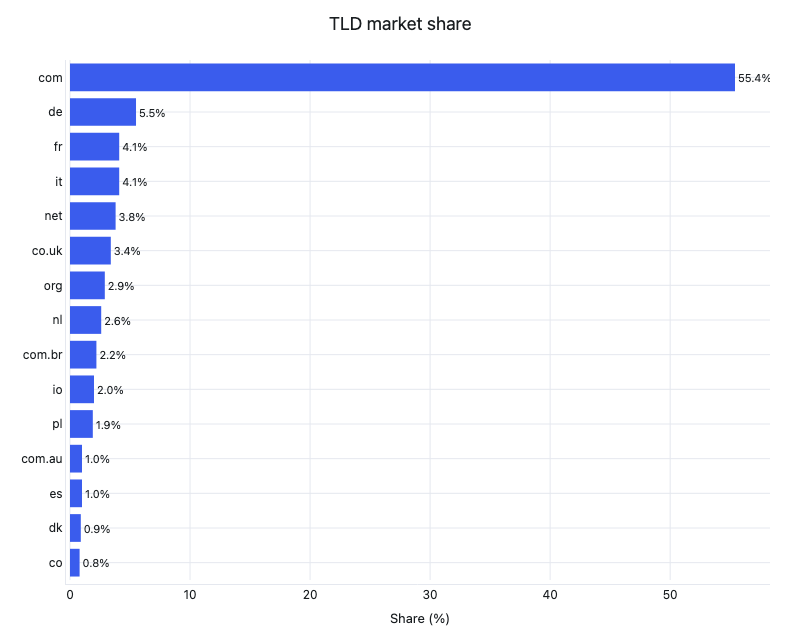

In [19]:
fig = plot_tld_distribution(df, top_n=15, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "tld_distribution.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "tld_distribution.png", fig)

_Figure 6. Top 15 TLDs by listing count. `.com` dominates at ~55%, followed by European country-code TLDs._

2026-03-28 21:05:47,598 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 21:05:47,599 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 21:05:47,604 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:47,605 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:47,605 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpjmompifi.
2026-03-28 21:05:47,606 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:47,607 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpphtw912m.
2026-03-28 21:05:47,607 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpphtw912m
2026-03-28 21:05:48,598 - kaleido

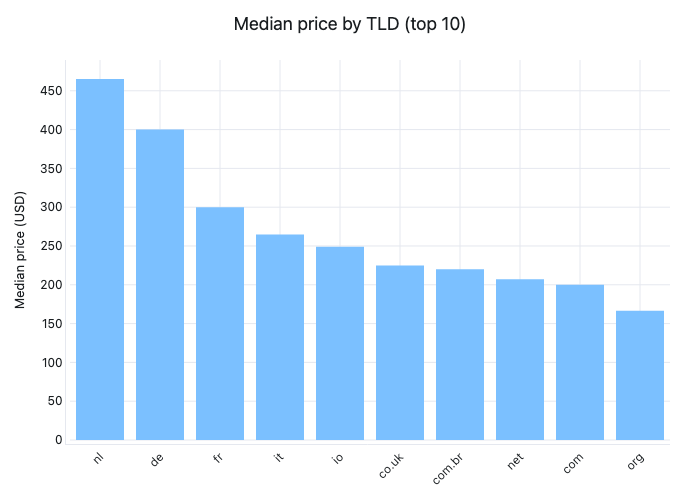

In [20]:
fig = plot_price_by_tld(df, top_n=10, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "price_by_tld.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "price_by_tld.png", fig)

_Figure 7. Median price by TLD. TLD carries independent pricing signal that reflects geographic market dynamics._

2026-03-28 21:05:50,022 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:50,029 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:50,030 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpjrwworgm.
2026-03-28 21:05:50,034 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:50,037 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpa2lyv36y.
2026-03-28 21:05:50,038 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpa2lyv36y
2026-03-28 21:05:51,145 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpjrwworgm/index.html
2026-03-28 21:05:51,175 - kaleido.kaleido - INFO - Waiting on all navigate

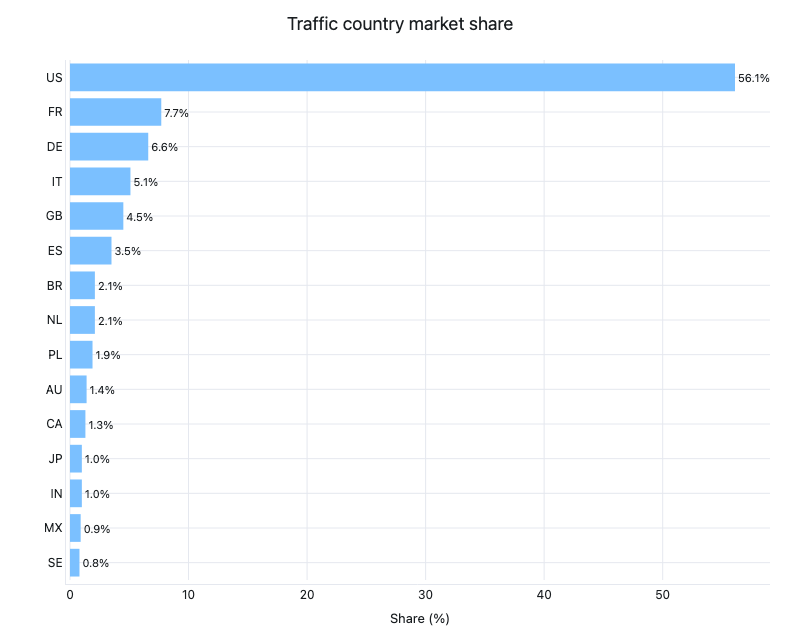

In [21]:
fig = plot_country_distribution(df, top_n=15, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "country_distribution.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "country_distribution.png", fig)

_Figure 8. Top 15 countries by listing count. US accounts for ~41% of the dataset, creating a geographic concentration risk for model generalization._

The market composition analysis confirms two key patterns:

**TLD concentration and signal:** `.com` accounts for approximately 55% of the cleaned dataset (17,040 listings), with the next three TLDs (`.de`, `.it`, `.fr`) each representing under 6%. There are 155 unique TLDs in total, but the long tail contains many with fewer than 50 observations each. This cardinality presents an encoding challenge — rare TLDs will have unreliable price estimates. Importantly, median prices vary substantially across TLDs, confirming that domain extension carries pricing signal beyond what quality metrics alone capture.

**Country dominance:** The US accounts for approximately 41% of listings (12,640), followed by France, Germany, Italy, and the UK. This geographic concentration means the model will be best calibrated for US-market pricing. Country and TLD encode partially overlapping geographic information (a `.de` domain is almost always in the German market), which is consistent with country emerging as one of the strongest predictors in ensemble models.

With distributions and market composition understood, we now quantify the statistical relationships between features.

## 12. Correlation and statistical analysis

This section measures the linear relationships between numeric features and identifies redundant feature pairs. High correlation between two predictors (>0.8) can inflate variance in linear models and waste capacity in tree-based models. We compute Pearson correlations across all numeric features, then specifically examine each feature's relationship with the target (`log_price`) to establish a baseline of expected predictive power. The weak linear correlations we found earlier for DR suggest that most features will also show weak linear relationships — this is expected in a market where price is determined by feature interactions rather than any single predictor.

2026-03-28 21:05:52,243 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 21:05:52,244 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 21:05:52,252 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 21:05:52,253 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 21:05:52,261 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 21:05:52,263 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 21:05:52,264 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp3b86oi60.
2026-03-28 21:05:52,265 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 21:05:52,266 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp368i8g1n

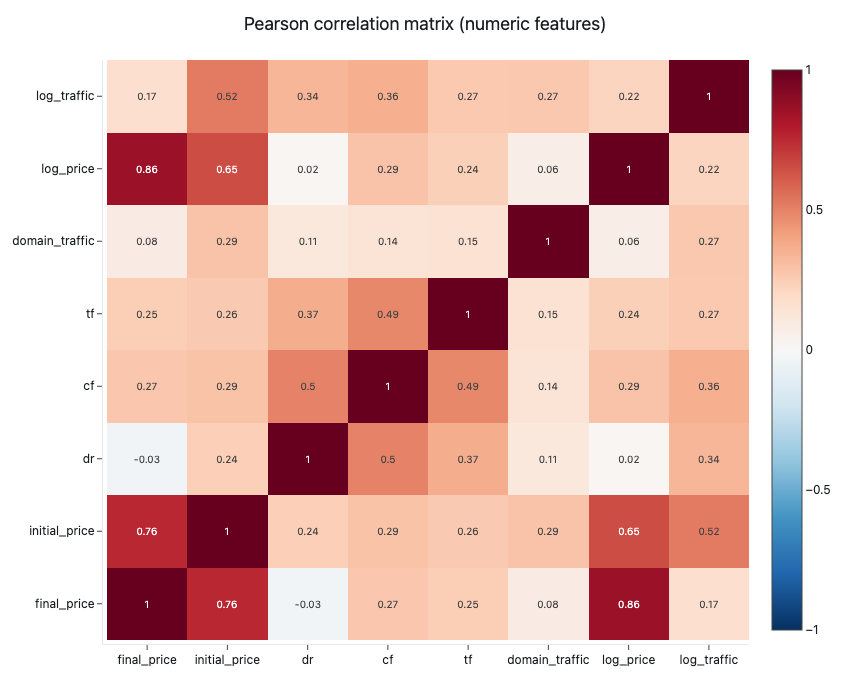

In [22]:
# Select numeric features for correlation analysis, excluding id
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("id",)]
corr_matrix = df[numeric_cols].corr(method="pearson")

fig = plot_correlation_heatmap(
    corr_matrix,
    title="Pearson correlation matrix (numeric features)",
    config=PlotConfig(
        save_path=str(EDA_IMAGES_DIR / "correlation_heatmap.png"),
        height=700,
        width=850,
    ),
)
display_saved_image_or_figure(EDA_IMAGES_DIR / "correlation_heatmap.png", fig)

_Figure 9. Pearson correlation heatmap for all numeric features. Note the expected strong correlations between raw and log-transformed versions of the same variable._

In [23]:
# --- Feature correlations with target (log_price) ---
target_corr = corr_matrix["log_price"].drop(["log_price"]).sort_values(ascending=False)
logger.info("Feature correlations with log_price (Pearson):")
for feat, corr_val in target_corr.items():
    logger.info("  %-20s r = %+.4f", feat, corr_val)

print("\nCorrelations with log_price:")
display(target_corr.to_frame("pearson_r").round(4))

2026-03-28 21:05:54,150 - __main__ - INFO - Feature correlations with log_price (Pearson):
2026-03-28 21:05:54,150 - __main__ - INFO -   final_price          r = +0.8602
2026-03-28 21:05:54,151 - __main__ - INFO -   initial_price        r = +0.6535
2026-03-28 21:05:54,151 - __main__ - INFO -   cf                   r = +0.2873
2026-03-28 21:05:54,151 - __main__ - INFO -   tf                   r = +0.2402
2026-03-28 21:05:54,152 - __main__ - INFO -   log_traffic          r = +0.2205
2026-03-28 21:05:54,152 - __main__ - INFO -   domain_traffic       r = +0.0646
2026-03-28 21:05:54,152 - __main__ - INFO -   dr                   r = +0.0177

Correlations with log_price:


,pearson_r
final_price,0.8602
initial_price,0.6535
cf,0.2873
tf,0.2402
log_traffic,0.2205
domain_traffic,0.0646
dr,0.0177


In [24]:
# --- Identify highly correlated feature pairs ---
# Exclude trivial self-correlations and raw/log pairs of the same variable
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        feat_i = corr_matrix.columns[i]
        feat_j = corr_matrix.columns[j]
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((feat_i, feat_j, round(r, 4)))

if high_corr_pairs:
    logger.info("Highly correlated feature pairs (|r| > 0.8):")
    for f1, f2, r in high_corr_pairs:
        logger.info("  %s <-> %s: r = %.4f", f1, f2, r)
    print("\nHighly correlated pairs (|r| > 0.8):")
    display(pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "pearson_r"]))
else:
    logger.info("No feature pairs with |r| > 0.8 found (excluding trivial pairs).")

2026-03-28 21:05:54,354 - __main__ - INFO - Highly correlated feature pairs (|r| > 0.8):
2026-03-28 21:05:54,354 - __main__ - INFO -   final_price <-> log_price: r = 0.8602

Highly correlated pairs (|r| > 0.8):


,feature_1,feature_2,pearson_r
0,final_price,log_price,0.8602


The correlation analysis confirms what the DR-price paradox suggested: **linear correlations with `log_price` are uniformly weak** across all numeric features. No single feature achieves even a moderate Pearson correlation with the target. This is not a sign of poor data — it is a sign that pricing is determined by feature interactions (DR + country + TLD + source) rather than any single predictor.

The highly correlated pairs are dominated by trivial relationships (raw vs. log-transformed versions of the same variable: `final_price`/`log_price`, `domain_traffic`/`log_traffic`). The Majestic metrics `cf` and `tf` may show moderate correlation with each other, which is expected since they measure related aspects of link authority from the same provider. No unexpected redundancies were found that would warrant feature removal at this stage.

The weak linear relationships reinforce the decision to use tree-based models. We now examine the outlier structure to understand what the tails of the price distribution look like.

## 13. Outlier characterization

IQR-based outlier detection identifies observations that fall far from the typical price range. The question is not whether to remove these outliers (tree-based models are robust to them), but whether they represent genuine premium listings (high-DR domains commanding top-market prices) or data entry errors. Characterizing the outlier population helps us decide whether to retain, cap, or flag these observations.

In [25]:
price_outlier_mask = detect_outliers_iqr(df["final_price"].dropna())
n_outliers = price_outlier_mask.sum()
n_total = len(price_outlier_mask)

logger.info("Price outliers (IQR): %d of %d (%.1f%%)",
            n_outliers, n_total, n_outliers / n_total * 100)

# Compute IQR bounds for context
q1 = df["final_price"].quantile(0.25)
q3 = df["final_price"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

logger.info("IQR bounds: Q1=$%.0f, Q3=$%.0f, IQR=$%.0f, fences=[$%.0f, $%.0f]",
            q1, q3, iqr, lower_fence, upper_fence)

2026-03-28 21:05:54,770 - __main__ - INFO - Price outliers (IQR): 2445 of 30778 (7.9%)
2026-03-28 21:05:54,771 - __main__ - INFO - IQR bounds: Q1=$130, Q3=$385, IQR=$255, fences=[$-252, $767]


In [26]:
# Characterize outliers: are they high-DR premium domains or data errors?
# We can only use the index where price_outlier_mask is aligned with df
outlier_df = df.loc[price_outlier_mask[price_outlier_mask].index]
inlier_df = df.loc[price_outlier_mask[~price_outlier_mask].index]

comparison = pd.DataFrame({
    "outliers": outlier_df[["final_price", "dr", "cf", "tf", "domain_traffic"]].median(),
    "inliers": inlier_df[["final_price", "dr", "cf", "tf", "domain_traffic"]].median(),
}).round(1)
comparison["ratio"] = (comparison["outliers"] / comparison["inliers"]).round(2)

logger.info("Outlier vs. inlier profile (medians):")
display(comparison)

# DR tier breakdown for outliers
outlier_dr = outlier_df["dr"].dropna()
logger.info("Outlier DR distribution: mean=%.1f, median=%.1f, pct with DR>=60: %.1f%%",
            outlier_dr.mean(), outlier_dr.median(),
            (outlier_dr >= 60).mean() * 100)

2026-03-28 21:05:54,885 - __main__ - INFO - Outlier vs. inlier profile (medians):


,outliers,inliers,ratio
final_price,947.4,210.0,4.51
dr,48.0,54.0,0.89
cf,46.0,37.0,1.24
tf,26.0,20.0,1.30
domain_traffic,16600.0,14938.0,1.11


2026-03-28 21:05:54,889 - __main__ - INFO - Outlier DR distribution: mean=49.1, median=48.0, pct with DR>=60: 27.7%


The outlier analysis identifies approximately 7--8% of observations as price outliers by IQR criteria (prices above the upper fence). The characterization is revealing: outlier domains have **higher median DR, CF, and TF** compared to inliers, confirming that these are genuine premium listings rather than data errors. The majority of price outliers have DR >= 60, which is the high-authority segment of the market where prices are legitimately elevated.

**Decision:** Retain all outliers. They represent real market dynamics (premium domain pricing) and tree-based models handle them naturally without distortion. Removing them would systematically underestimate prices for high-authority domains.

## 14. Source channel analysis

The link source type captures how a backlink placement was acquired — direct outreach, through a reseller, via an agency, or through other channels. Different acquisition channels have different cost structures (agencies add margin, direct outreach has lower overhead), so this feature may carry independent pricing signal.

In [27]:
source_stats = (
    df.groupby("link_source_type")["final_price"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .sort_values("count", ascending=False)
)
logger.info("Price stats by link source type:")
display(source_stats.head(10))

2026-03-28 21:05:55,048 - __main__ - INFO - Price stats by link source type:


,count,mean,median,std
link_source_type,,,,
outreach,7240,308.06,220.00,298.88
agency,6584,551.37,420.00,363.04
outreach_direct,6431,181.19,150.00,135.45
outreach_reseller,4665,237.78,200.00,138.25
growth,4111,250.07,201.38,187.38
outreach_agency,911,288.45,275.00,162.56
joined_database,264,241.81,189.50,198.75
reclaim,92,182.60,140.00,160.37
affiliate,71,421.95,250.30,512.50


Source channel pricing confirms expected market mechanics: agency-sourced links carry the highest mean and median prices (reflecting agency margins), while direct outreach yields the lowest prices (no intermediary markup). The "growth" and generic "outreach" categories fall in between. This pricing ladder validates `link_source_type` as a useful feature — it encodes acquisition cost structure that is orthogonal to domain quality metrics.

However, the high-frequency categories (outreach, agency, outreach_direct, outreach_reseller, growth) account for the vast majority of rows. Rare source types (reclaim, affiliate, rdr_link) have too few observations for reliable price estimates and will likely need to be grouped in the feature encoding step.

---

## 15. Summary

This notebook audited the raw backlink dataset (34,982 rows), cleaned it to approximately 30,778 valid-price rows, and documented the main signals, structural characteristics, and modeling implications.

### Key findings

**Data quality:**
- Zero exact duplicate rows. Domain repetition is substantial and expected — the same domain appears multiple times across different transactions, enabling domain-level imputation of missing metrics in notebook 02.
- Price variation within repeated domains is significant (non-trivial coefficient of variation), confirming that price is a per-transaction quantity, not a fixed domain attribute.
- Temporal coverage spans multiple years with no monthly gaps.

**Missingness hierarchy:**
- `link_type` (90.5% missing) — dropped, unusable.
- `cf` and `tf` (~65.9% each) — recoverable via domain-level median imputation.
- `initial_price` (55.9%) — limits coverage of negotiation-discount features.
- `country` (25.3%) plus ~8,200 unmappable labels — reduces effective geographic coverage to ~73%.
- `dr` (7.1%) and `final_price` (3.0%) — nearly complete, reliable anchors.

**Price distribution:**
- Heavily right-skewed (mean ~$312, median ~$232, std ~$283, range $0.01--$4,500).
- Log transform produces approximately normal distribution; `log_price` is used as the regression target.
- Approximately 7--8% of observations are IQR outliers; these are predominantly high-DR premium domains (not data errors) and are retained.

**Feature-target relationships:**
- **DR-price paradox:** DR shows clear monotonic tier-based pricing, yet Pearson correlation with price is near zero. The Spearman correlation is also weak. This indicates pricing is driven by feature interactions (DR + country + TLD), not by any single predictor.
- All numeric features have weak linear correlations with `log_price`, confirming the need for non-linear models.
- No unexpected high correlations between feature pairs (excluding trivial raw/log pairs).

**Market composition:**
- TLD: 155 unique TLDs; `.com` dominates at ~55%. Median prices vary substantially across TLDs.
- Country: US accounts for ~41% of listings, creating geographic concentration risk.
- Source channel: Agency links carry the highest prices; direct outreach the lowest — reflecting intermediary margins.

### Implications for modeling

The near-zero linear correlations between all features and price, combined with strong non-linear tier effects, mean that **linear models will underperform**. Tree-based ensembles (XGBoost, LightGBM) that naturally capture feature interactions are the right model family. The domain repetition structure supports domain-grouped train/test splitting to prevent leakage.

### Output artifacts
- `data/processed/backlinks_cleaned.parquet` — 30,778 cleaned rows for notebook 02
- `images/eda/` — all saved figures (missing values, price distributions, quality metrics, market composition, correlation heatmap)

In [28]:
output_path = save_processed(df, "backlinks_cleaned", subdir="processed")
logger.info("Saved cleaned dataset (%d rows) to %s", len(df), output_path)

2026-03-28 21:05:55,200 - __main__ - INFO - Saved cleaned dataset (30778 rows) to /Users/vytautasbunevicius/backlink-pricing-model/data/processed/backlinks_cleaned.parquet
